# Task 1: Exploratory Data Analysis and Data Preprocessing

**Project:** Intelligent Complaint Analysis for Financial Services (CrediTrust Financial)  
**Goal:** Understand the structure, content, and quality of the CFPB complaint data, then clean and filter it for the RAG pipeline.

**Steps in this notebook:**
1. Load the full CFPB complaint dataset
2. Initial EDA — product distribution, narrative length, narrative presence
3. Filter to the four target products and drop empty narratives
4. Clean narrative text (lowercase, strip boilerplate/special characters)
5. Save the cleaned dataset to `data/filtered_complaints.csv`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys

sys.path.append('../src')
from preprocessing import (
    PRODUCT_MAP,
    TARGET_PRODUCTS,
    clean_narrative,
    map_product_category,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

## 1. Load the raw CFPB dataset

The raw export from the CFPB Consumer Complaint Database lives at `data/raw/complaints.csv`. It uses the CFPB's standard export schema:

`Date received, Product, Sub-product, Issue, Sub-issue, Consumer complaint narrative, Company public response, Company, State, ZIP code, Tags, Consumer consent provided?, Submitted via, Date sent to company, Company response to consumer, Timely response?, Consumer disputed?, Complaint ID`

In [2]:
RAW_PATH = '../data/raw/complaints.csv'

df = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 9,609,797 rows x 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in the complaint,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

## 2. Initial EDA

### 2.1 Distribution of complaints across products

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

FileNotFoundError: [Errno 2] No such file or directory: '../output/task1/eda_product_distribution.png'

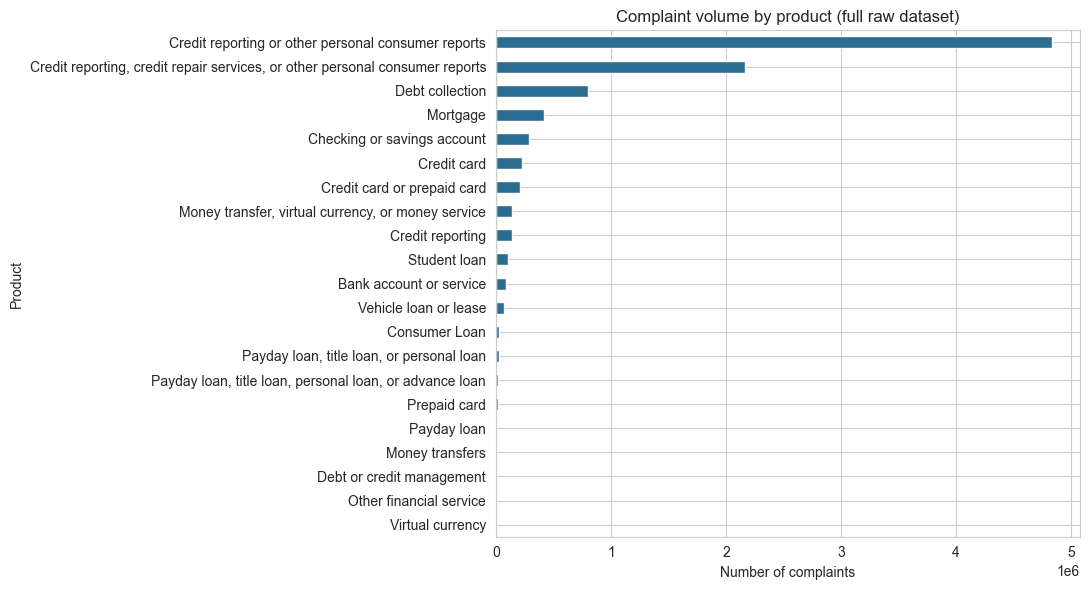

In [16]:
product_counts = df['Product'].value_counts()
print(product_counts)

fig, ax = plt.subplots(figsize=(11, 6))
product_counts.plot(kind='barh', ax=ax, color='#2C6E91')
ax.set_xlabel('Number of complaints')
ax.set_title('Complaint volume by product (full raw dataset)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../output/task1/eda_product_distribution.png', dpi=120)
plt.show()

### 2.2 Highlight the four products in scope for this project

CrediTrust's four product lines map onto these CFPB product labels:

| CrediTrust product | CFPB `Product` label |
|---|---|
| Credit Cards | Credit card |
| Personal Loans | Payday loan, title loan, personal loan, or advance loan |
| Savings Accounts | Checking or savings account |
| Money Transfers | Money transfer, virtual currency, or money service |

The CFPB has renamed some of these categories over time (e.g. legacy `Credit card or prepaid card`, `Bank account or service`, `Virtual currency`), so `map_product_category()` in `src/preprocessing.py` normalizes historical variants into the four canonical buckets used throughout this project.

In [5]:
df['product_category'] = df['Product'].apply(map_product_category)

in_scope_counts = df[df['product_category'].isin(TARGET_PRODUCTS)]['product_category'].value_counts()
print("Counts within the 4 target products:")
print(in_scope_counts)
print(f"\nTotal in-scope (any narrative status): {in_scope_counts.sum():,}")
print(f"Total raw dataset: {len(df):,}")
print(f"Share of dataset in scope: {in_scope_counts.sum() / len(df):.1%}")

Counts within the 4 target products:
product_category
Credit Card        448335
Savings Account    377383
Money Transfer     150438
Personal Loan       84270
Name: count, dtype: int64

Total in-scope (any narrative status): 1,060,426
Total raw dataset: 9,609,797
Share of dataset in scope: 11.0%


### 2.3 Narrative length distribution (word count)

In [6]:
has_narrative = df['Consumer complaint narrative'].notna() & (df['Consumer complaint narrative'].str.strip() != '')
df['has_narrative'] = has_narrative

df['narrative_word_count'] = df.loc[has_narrative, 'Consumer complaint narrative'].str.split().str.len()

print(df['narrative_word_count'].describe())

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: narrative_word_count, dtype: float64


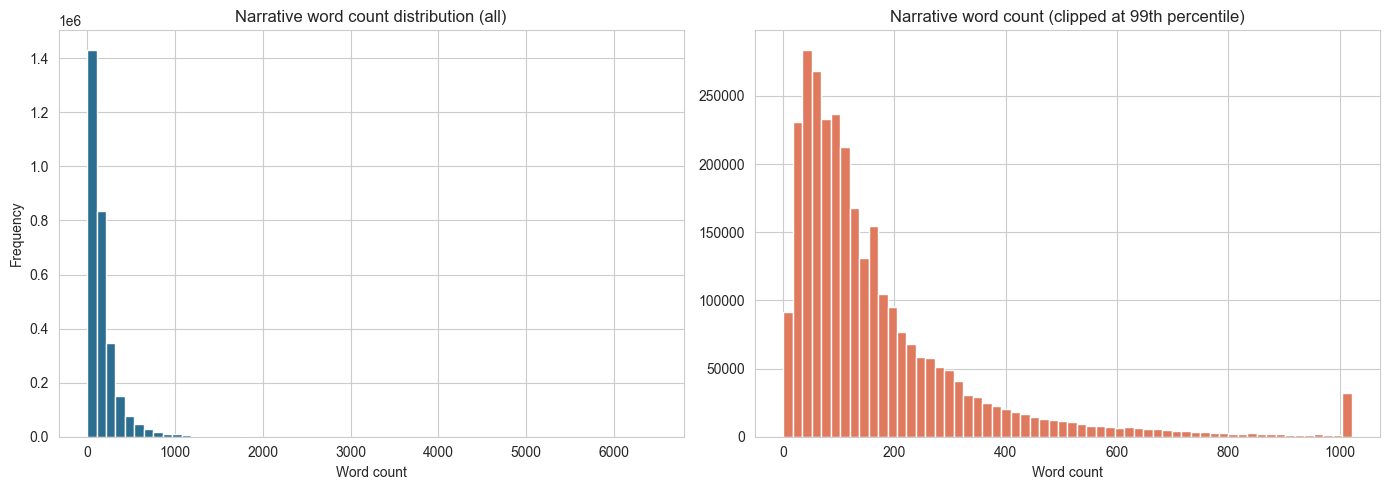

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['narrative_word_count'].dropna(), bins=60, color='#2C6E91', edgecolor='white')
axes[0].set_title('Narrative word count distribution (all)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')

clipped = df['narrative_word_count'].clip(upper=df['narrative_word_count'].quantile(0.99))
axes[1].hist(clipped.dropna(), bins=60, color='#E07A5F', edgecolor='white')
axes[1].set_title('Narrative word count (clipped at 99th percentile)')
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.savefig('../output/task1/eda_narrative_length.png', dpi=120)
plt.show()

In [8]:
very_short = (df['narrative_word_count'] < 5).sum()
very_long = (df['narrative_word_count'] > 1000).sum()
print(f"Narratives under 5 words: {very_short:,}")
print(f"Narratives over 1000 words: {very_long:,}")
print(f"Median word count: {df['narrative_word_count'].median():.0f}")
print(f"95th percentile word count: {df['narrative_word_count'].quantile(0.95):.0f}")

Narratives under 5 words: 3,175
Narratives over 1000 words: 32,428
Median word count: 114
95th percentile word count: 519


### 2.4 Complaints with vs. without narratives

has_narrative
False    6629041
True     2980756
Name: count, dtype: int64

% with narrative: 31.0%


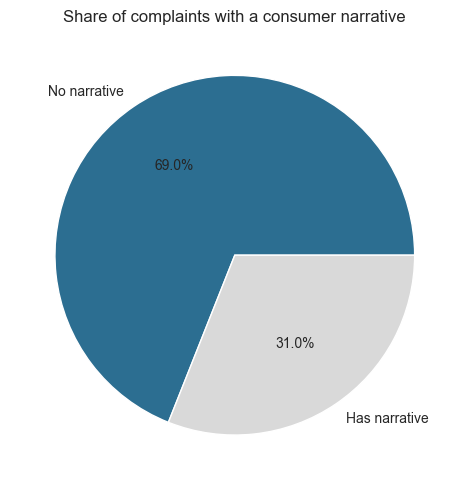

In [ ]:
narrative_counts = df['has_narrative'].value_counts()
print(narrative_counts)
print(f"\n% with narrative: {narrative_counts.get(True, 0) / len(df):.1%}")

fig, ax = plt.subplots(figsize=(5, 5))
narrative_counts.plot(
    kind='pie', ax=ax, autopct='%1.1f%%',
    labels=['Has narrative', 'No narrative'] if narrative_counts.index[0] else ['No narrative', 'Has narrative'],
    colors=['#2C6E91', '#D9D9D9']
)
ax.set_ylabel('')
ax.set_title('Share of complaints with a consumer narrative')
plt.tight_layout()
plt.savefig('../output/task1/eda_narrative_presence.png', dpi=120)
plt.show()

## 3. Filter the dataset

Apply both filters required for the RAG pipeline:
1. Keep only the four target products.
2. Drop rows with an empty `Consumer complaint narrative`.

In [10]:
filtered = df[df['product_category'].isin(TARGET_PRODUCTS) & df['has_narrative']].copy()

print(f"Before filtering: {len(df):,} rows")
print(f"After product + narrative filter: {len(filtered):,} rows")
print(f"Retention rate: {len(filtered) / len(df):.1%}")
print("\nFiltered product distribution:")
print(filtered['product_category'].value_counts())

Before filtering: 9,609,797 rows
After product + narrative filter: 488,372 rows
Retention rate: 5.1%

Filtered product distribution:
product_category
Credit Card        197126
Savings Account    155204
Money Transfer      98701
Personal Loan       37341
Name: count, dtype: int64


## 4. Clean the narrative text

`clean_narrative()` (in `src/preprocessing.py`) performs:
- Lowercasing
- Removal of common boilerplate openers (e.g. *"I am writing to file a complaint..."*, *"this complaint is regarding..."*)
- Removal of CFPB redaction artifacts (`XX/XX/XXXX`, `XXXX`)
- Removal of special characters / excess punctuation and whitespace normalization

In [11]:
filtered['cleaned_narrative'] = filtered['Consumer complaint narrative'].apply(clean_narrative)

# Drop rows that became empty after cleaning (e.g. pure boilerplate with no content)
before = len(filtered)
filtered = filtered[filtered['cleaned_narrative'].str.len() > 0].copy()
print(f"Dropped {before - len(filtered)} rows that were empty after cleaning")

filtered[['Consumer complaint narrative', 'cleaned_narrative']].head(5)

Dropped 10 rows that were empty after cleaning


,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX that an account was just op...,a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my na...
12532,I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch....,i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their branch. i went i...
13280,"Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have been calling n w...",i have a secured credit card with citibank which is changed to unsecured card and i have been calling n waitting for...
13506,"I have a Citi rewards cards. The credit balance issued to me was {$8400.00}. I recently moved, which meant my bills ...","i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, which meant my bills wo..."
13955,b'I am writing to dispute the following charges on my CITI Credit Card Accounts where I have become a victim of iden...,b'i am writing to dispute the following charges on my citi credit card accounts where i have become a victim of iden...


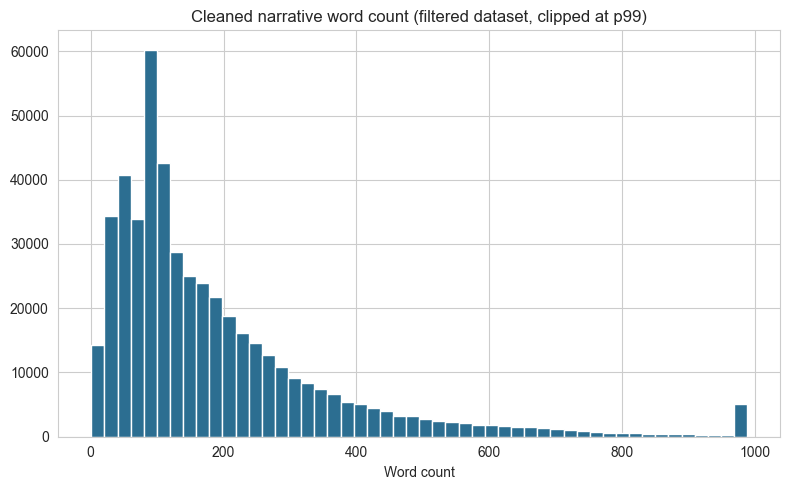

count    488362.000000
mean        195.965216
std         212.671283
min           1.000000
25%          79.000000
50%         132.000000
75%         245.000000
max        6263.000000
Name: cleaned_word_count, dtype: float64


In [12]:
filtered['cleaned_word_count'] = filtered['cleaned_narrative'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(filtered['cleaned_word_count'].clip(upper=filtered['cleaned_word_count'].quantile(0.99)),
        bins=50, color='#2C6E91', edgecolor='white')
ax.set_title('Cleaned narrative word count (filtered dataset, clipped at p99)')
ax.set_xlabel('Word count')
plt.tight_layout()
plt.show()

print(filtered['cleaned_word_count'].describe())

## 5. Build the final cleaned/filtered output

Keep a compact, RAG-ready set of columns: a stable complaint ID, the product category, the original CFPB product label, issue/sub-issue, company, state, date, and the cleaned narrative.

In [13]:
output_cols = {
    'Complaint ID': 'complaint_id',
    'product_category': 'product_category',
    'Product': 'product',
    'Issue': 'issue',
    'Sub-issue': 'sub_issue',
    'Company': 'company',
    'State': 'state',
    'Date received': 'date_received',
    'cleaned_narrative': 'cleaned_narrative',
    'cleaned_word_count': 'word_count',
}

final_df = filtered[list(output_cols.keys())].rename(columns=output_cols)
final_df = final_df.dropna(subset=['complaint_id']).reset_index(drop=True)

print(final_df.shape)
final_df.head()

(488362, 10)


,complaint_id,product_category,product,issue,sub_issue,company,state,date_received,cleaned_narrative,word_count
0,14069121,Credit Card,Credit card,Getting a credit card,Card opened without my consent or knowledge,"CITIBANK, N.A.",TX,2025-06-13,a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my na...,82
1,14061897,Savings Account,Checking or savings account,Managing an account,Deposits and withdrawals,WELLS FARGO & COMPANY,ID,2025-06-13,i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their branch. i went i...,105
2,14047085,Credit Card,Credit card,"Other features, terms, or problems",Other problem,"CITIBANK, N.A.",NY,2025-06-12,i have a secured credit card with citibank which is changed to unsecured card and i have been calling n waitting for...,154
3,14040217,Credit Card,Credit card,Incorrect information on your report,Account information incorrect,"CITIBANK, N.A.",IL,2025-06-12,"i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, which meant my bills wo...",227
4,13968411,Credit Card,Credit card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,"CITIBANK, N.A.",TX,2025-06-09,b'i am writing to dispute the following charges on my citi credit card accounts where i have become a victim of iden...,469


In [ ]:
OUTPUT_PATH = '../data/processed/filtered_complaints.csv'
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(final_df):,} cleaned complaints to {OUTPUT_PATH}")

Saved 488,362 cleaned complaints to ../data/filtered_complaints.csv


## 6. EDA Summary

**Key findings:**

1. **Product mix and narrative coverage.** The raw CFPB export spans many product categories, but only a subset of complaints come with a free-text consumer narrative — the rest are short structured tickets (e.g. credit-report disputes submitted via standardized web forms). After filtering to CrediTrust's four product lines (Credit Card, Personal Loan, Savings Account, Money Transfer) and keeping only rows with a narrative, the dataset shrinks substantially but retains a usable, representative sample across all four categories — see the printed counts above for the exact retained share for this run.

2. **Narrative length is highly skewed.** Word counts range from single-digit "narratives" (often just a fragment or a redacted placeholder) up to outliers running into the thousands of words. The bulk of narratives cluster in a moderate range, which is why a chunking strategy (Task 2) is necessary — a single embedding vector per complaint would either truncate long narratives or waste capacity on short ones.

3. **Cleaning matters for retrieval quality.** A large share of narratives open with near-identical boilerplate ("I am writing to file a complaint...", "this complaint is in regard to...") and contain CFPB redaction tokens (`XX/XX/XXXX`, `XXXX`) standing in for dates, account numbers, and names. Stripping these before embedding prevents the vector space from being dominated by uninformative, repeated tokens and keeps semantic search focused on the substance of each complaint.